# TSV (Trainable Steering Vector) Fine-Tuning on OpenCLIP
## Complete Runnable Guide for Google Colab

This notebook fine-tunes **OpenCLIP ViT-B/32** with **TSV (Trainable
Steering Vector)** — a lightweight technique that freezes the entire
backbone and trains a single small vector added to the residual stream at
one transformer layer, instead of attaching adapters to `Linear` layers
(as LoRA/VeRA/DoRA do).

It covers: data setup (cached in your own Drive so you don't re-download
every session), a single main TSV run, and a full 3-phase study sweeping
layer position, placement (`attn`/`mlp`/`residual`/combinations), and
steering strength -- with graphs and saved results for each.

## 1. Setup and Installation

In [1]:
# Mount Google Drive (needed later for saving results, and if your
# professor's dataset folder is shared into your own Drive)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
try:
    import gdown
    print("Required packages already present, skipping install.")
except ImportError:
    import subprocess
    import sys

    packages = [
        'transformers',
        'torch',
        'torchvision',
        'accelerate',
        'datasets',
        'numpy',
        'matplotlib',
        'tqdm',
        'scikit-learn',
        'gdown',
    ]

    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
    print("Installation complete!")


Required packages already present, skipping install.


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 42.41 GB


## 2. Import Libraries and Setup

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## 3. Data Preparation

**Why this section is structured the way it is:** every second your Colab
runtime is connected to a GPU costs you compute quota, whether you're
downloading, training, or just fixing a typo. Re-downloading the dataset
from your professor's Drive folder on *every single session* wastes that
time for no reason. So the pattern here is:

1. **First time ever**: download once from your professor's shared Drive
   folder, then save a permanent copy into **your own** Drive.
2. **Every session after that**: just copy from your own Drive (same
   Google account -> fast, no real network download) instead of
   downloading from your professor's link again.
3. If your runtime disconnects and you reconnect, just re-run this
   section -- it will find the cached copy in your Drive and skip the
   slow path automatically.

In [5]:
import os
import shutil

# Your own Drive -- this is where we cache a permanent copy of the dataset
# so we never have to re-download it after the first time.
DRIVE_CACHE_DIR = '/content/drive/MyDrive/cifar10_cache'
DRIVE_CACHE_PATH = os.path.join(DRIVE_CACHE_DIR, 'cifar-10-batches-py')

# Where torchvision.datasets.CIFAR10 expects to find the data locally
LOCAL_DATA_DIR = 'data'
LOCAL_CACHE_PATH = os.path.join(LOCAL_DATA_DIR, 'cifar-10-batches-py')

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_CACHE_PATH):
    # Already unpacked on THIS session's local disk (e.g. you re-ran this
    # cell without disconnecting) -- nothing to do.
    print(f"Already present locally at {LOCAL_CACHE_PATH}, skipping.")

elif os.path.exists(DRIVE_CACHE_PATH):
    # Fast path: we've cached this in your own Drive before. Copying
    # within Google's own storage is quick -- no external download.
    print("Found cached dataset in your Drive -- copying to local disk...")
    shutil.copytree(DRIVE_CACHE_PATH, LOCAL_CACHE_PATH)
    print(f"Copied to {LOCAL_CACHE_PATH}")

else:
    # Slow path, first time only: download from your professor's shared
    # Drive folder, then save a permanent copy into your own Drive for
    # every future session.
    print("Not cached yet -- downloading from professor's Drive folder...")
    folder_id = '1NZyI_UOHtSOlqpoivZqBiITy1hvM0Idc'
    !gdown --folder --id {folder_id}

    # See exactly what landed on disk before assuming a folder name --
    # if your professor's folder isn't literally named 'cifar-10-batches-py',
    # update `downloaded_name` below to match what gets printed here.
    print("Downloaded contents of current directory:", os.listdir('.'))
    downloaded_name = 'cifar-10-batches-py'

    if not os.path.exists(downloaded_name):
        raise FileNotFoundError(
            f"Couldn't find '{downloaded_name}' after download. Check the "
            f"directory listing printed above and update `downloaded_name` "
            f"to match what actually got downloaded."
        )

    # Move into place for torchvision
    shutil.move(downloaded_name, LOCAL_CACHE_PATH)
    print(f"Moved to {LOCAL_CACHE_PATH}")

    # Save a permanent copy to YOUR Drive so future sessions skip the
    # download entirely
    os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)
    shutil.copytree(LOCAL_CACHE_PATH, DRIVE_CACHE_PATH)
    print(f"Cached a permanent copy to {DRIVE_CACHE_PATH} for next time.")

print("\nFinal local data contents:", os.listdir(LOCAL_DATA_DIR))


Found cached dataset in your Drive -- copying to local disk...
Copied to data/cifar-10-batches-py

Final local data contents: ['cifar-10-batches-py']


In [6]:
# Define data transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Load CIFAR-10 dataset
# FIX: download=False now -- the data is already sitting in ./data from the
# Google Drive download above, so we don't need (or want) torchvision to
# reach out to the official site at all.
print("Loading CIFAR-10 dataset from local ./data ...")
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

# Use subset for faster training
subset_size_train = 5000  # 10% of training data
subset_size_test = 1000   # 20% of test data

train_dataset, _ = random_split(
    train_dataset,
    [subset_size_train, len(train_dataset) - subset_size_train]
)

test_dataset, _ = random_split(
    test_dataset,
    [subset_size_test, len(test_dataset) - subset_size_test]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: 10")
print(f"Input shape: (3, 32, 32)")


Loading CIFAR-10 dataset from local ./data ...
Train dataset size: 5000
Test dataset size: 1000
Number of classes: 10
Input shape: (3, 32, 32)


In [7]:
# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 79
Test batches: 16


## 4. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """Resize CIFAR-10 images (32x32) to target size for ViT"""
    from torchvision.transforms import Resize
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, train_loader, optimizer, criterion, device, epoch, total_epochs):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)

    for images, labels in pbar:
        # Resize images for ViT
        images = resize_images(images, target_size=224)
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        pbar.set_postfix({
            'loss': total_loss / (total / BATCH_SIZE),
            'acc': 100 * correct / total
        })

    return total_loss / len(train_loader), 100 * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", leave=False)
        for images, labels in pbar:
            # Resize images for ViT
            images = resize_images(images, target_size=224)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return total_loss / len(test_loader), accuracy, f1

def count_parameters(model):
    """Count trainable and total parameters"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 4.1 Global training hyperparameters

Set **once**, here, and reused as-is everywhere below -- nothing later in
the notebook redefines or overrides these.

In [9]:
EPOCHS = 10
LEARNING_RATE = 0.01

print(f"EPOCHS = {EPOCHS}")
print(f"LEARNING_RATE = {LEARNING_RATE}")
print("(same for LoRA, VeRA, DoRA, and TSV -- fair comparison)")


EPOCHS = 10
LEARNING_RATE = 0.01
(same for LoRA, VeRA, DoRA, and TSV -- fair comparison)


## 5. TSV (Trainable Steering Vector) Fine-Tuning

TSV freezes the entire backbone and adds one small trainable vector `v`
directly to the **output of a transformer block** (the residual stream):

```
h_out = block(h_in)          # normal frozen block computation
h_out = h_out + lam * v      # TSV steering
```

Only `v` (and, for our classification setup, the linear classifier head)
is trained -- via a PyTorch **forward hook**, no need to modify the
model's source code or pick individual `Linear` sub-modules.

We apply this to **OpenCLIP ViT-B/32** (the LAION-trained CLIP vision
tower, available on the HF Hub as `laion/CLIP-ViT-B-32-laion2B-s34B-b79K`),
loaded through `transformers.CLIPVisionModel`.

In [10]:
from transformers import CLIPVisionModel

# OpenCLIP ViT-B/32 weights, hosted on the HF Hub and loadable via `transformers`
OPENCLIP_MODEL_NAME = 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K'

# Load ONCE, just to inspect the module tree -- this tells us the exact
# attribute path to the transformer blocks (same exercise as timm's
# `model.blocks[i]` vs HF ViT's `model.vit.layers[i]`, but for CLIP).
_probe = CLIPVisionModel.from_pretrained(OPENCLIP_MODEL_NAME)
print(_probe)


config.json:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (position_embedding): Embedding(50, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (

In [11]:
# Reading the tree printed above: CLIPVisionModel -> encoder -> layers[i]
# (NOTE: this is specific to the current `transformers` version. Older
# versions wrapped it as `model.vision_model.encoder.layers[i]` instead --
# always confirm with print(model) rather than assuming the path.)
print(_probe.encoder.layers[0])

# Done inspecting -- free the memory before building the real model below.
del _probe


CLIPEncoderLayer(
  (self_attn): CLIPAttention(
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): CLIPMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [12]:
def get_transformer_blocks(model):
    """
    Return the list/ModuleList of transformer blocks for common ViT/CLIP
    implementations, so the rest of the code doesn't care which library the
    backbone came from.

    Covers:
      - timm ViT:                        model.blocks[i]
      - HF ViTModel:                      model.vit.layers[i]
      - HF CLIPVisionModel (current):     model.encoder.layers[i]
      - HF CLIPVisionModel (older ver.):  model.vision_model.encoder.layers[i]
      - open_clip (the `open_clip` pip package): model.visual.transformer.resblocks[i]
    """
    if hasattr(model, 'blocks'):                                        # timm
        return model.blocks
    if hasattr(model, 'vit') and hasattr(model.vit, 'layers'):           # HF ViTForImageClassification
        return model.vit.layers
    if hasattr(model, 'vision_model'):                                   # HF CLIPVisionModel (older versions)
        return model.vision_model.encoder.layers
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'layers'):   # HF CLIPVisionModel (current) / generic
        return model.encoder.layers
    if hasattr(model, 'visual') and hasattr(model.visual, 'transformer'):  # open_clip package
        return model.visual.transformer.resblocks
    if hasattr(model, 'backbone'):                                       # our own wrapper classes
        return get_transformer_blocks(model.backbone)
    raise ValueError(
        "Could not auto-detect transformer blocks. "
        "Run print(model) and locate the block list manually."
    )


class TSVHookManager(nn.Module):
    """
    Registers forward hooks that add a trainable steering vector `v`
    (scaled by `lam`) to the output of chosen transformer blocks.

    where:
        'residual'      -> add v to the WHOLE block's output (default, matches the TSV paper)
        'attn'          -> add v only to the self-attention sub-module's output
        'mlp'           -> add v only to the MLP sub-module's output
        'attn_mlp'      -> two separate vectors, one after attn, one after mlp
        'attn_residual' -> two separate vectors, one after attn, one after the whole block's output
        'mlp_residual'  -> two separate vectors, one after mlp, one after the whole block's output

    layer_indices:
        list of block indices to steer, e.g. [4] for a single early-middle
        layer, or list(range(num_layers)) to steer every layer.
    """
    def __init__(self, model, layer_indices, hidden_dim, lam=5.0, where='residual'):
        super().__init__()
        self.lam = lam
        self.where = where
        self._hook_handles = []
        self.tsv_vectors = nn.ParameterDict()

        blocks = get_transformer_blocks(model)

        for idx in layer_indices:
            block = blocks[idx]

            if where == 'residual':
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_res'] = v
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v)))

            elif where == 'attn':
                sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'mlp':
                sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'attn_mlp':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))

            elif where == 'attn_residual':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            elif where == 'mlp_residual':
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            else:
                raise ValueError(f"Unknown 'where' option: {where}")

    def _make_hook(self, v):
        def hook(module, inputs, output):
            # Some sub-modules (e.g. attention) return a tuple like
            # (hidden_states, attn_weights); only steer the hidden_states.
            if isinstance(output, tuple):
                hidden_states = output[0] + self.lam * v
                return (hidden_states,) + output[1:]
            return output + self.lam * v
        return hook

    @staticmethod
    def _find_submodule(block, candidate_names):
        for name in candidate_names:
            if hasattr(block, name):
                return getattr(block, name)
        raise AttributeError(
            f"None of {candidate_names} found on block. "
            f"Inspect it with print(block) to find the right attribute name."
        )

    def remove_hooks(self):
        for h in self._hook_handles:
            h.remove()
        self._hook_handles = []

print("get_transformer_blocks() and TSVHookManager (6 placement modes) defined!")


get_transformer_blocks() and TSVHookManager (6 placement modes) defined!


In [13]:
class TSVClassificationModel(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a trainable linear classification head.

    Only `self.tsv` and `self.classifier` show up in trainable_parameters() --
    the backbone itself is entirely frozen, same spirit as PEFT, but the
    'adapter' here is a steering vector added to the residual stream instead
    of a low-rank update to a Linear layer.
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.backbone = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_size = self.backbone.config.hidden_size
        num_layers = self.backbone.config.num_hidden_layers

        # Freeze the ENTIRE backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Default: one early-middle layer, matching the TSV paper's finding
        # that layers ~4-10 (out of ~12-32) work best for steering.
        if layer_indices is None:
            layer_indices = [num_layers // 3]

        self.tsv = TSVHookManager(
            self.backbone, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS / class token, final layer
        logits = self.classifier(cls_output)
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters()) + list(self.classifier.parameters())

print("TSVClassificationModel defined!")


TSVClassificationModel defined!


In [14]:
print("\n" + "="*60)
print("TSV FINE-TUNING")
print("="*60)

# Build the TSV model: single early-middle layer (auto-picked), steering the
# residual stream (where='residual') -- the default/simplest TSV setup.
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME,
    num_classes=10,
    layer_indices=None,   # None -> auto picks an early-middle layer
    lam=5.0,
    where='residual'
)
tsv_model = tsv_model.to(device)

trainable = sum(p.numel() for p in tsv_model.trainable_parameters())
total = sum(p.numel() for p in tsv_model.parameters())
print(f"\nTSV Model Summary:")
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Parameter efficiency: {100 * trainable / total:.4f}%")



TSV FINE-TUNING


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11


TSV Model Summary:
Total parameters: 87,464,458
Trainable parameters: 8,458
Parameter efficiency: 0.0097%


In [15]:
# Training setup for TSV (EPOCHS / LEARNING_RATE come from section 5.1)
# NOTE: optimizer only sees tsv_model.trainable_parameters() -- the TSV
# vector(s) + classifier head. Everything else in the backbone is frozen
# and never passed to the optimizer at all.
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(tsv_model.trainable_parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

tsv_history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_f1': []
}

best_acc = 0
start_time = datetime.now()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(tsv_model, train_loader, optimizer, criterion, device, epoch, EPOCHS)
    test_loss, test_acc, test_f1 = evaluate(tsv_model, test_loader, criterion, device)
    scheduler.step()

    tsv_history['train_loss'].append(train_loss)
    tsv_history['train_acc'].append(train_acc)
    tsv_history['test_loss'].append(test_loss)
    tsv_history['test_acc'].append(test_acc)
    tsv_history['test_f1'].append(test_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | F1: {test_f1:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        # No PEFT save_pretrained() here -- just save the small state dicts directly
        os.makedirs('./tsv_best_model', exist_ok=True)
        torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
        torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
        print(f"  ✓ TSV vector(s) + classifier head saved (best accuracy: {best_acc:.2f}%)")

training_time_tsv = (datetime.now() - start_time).total_seconds()
print(f"\nTSV Training completed in {training_time_tsv:.2f} seconds")
print(f"Best Test Accuracy: {best_acc:.2f}%")


Epoch 1/10
  Train Loss: 0.5496 | Train Acc: 82.66%
  Test Loss: 0.3516 | Test Acc: 89.30% | F1: 0.8940
  ✓ TSV vector(s) + classifier head saved (best accuracy: 89.30%)


Epoch 2/10
  Train Loss: 0.3470 | Train Acc: 88.54%
  Test Loss: 0.3488 | Test Acc: 88.50% | F1: 0.8847


Epoch 3/10
  Train Loss: 0.3512 | Train Acc: 87.80%
  Test Loss: 0.3247 | Test Acc: 89.20% | F1: 0.8933


Epoch 4/10
  Train Loss: 0.3296 | Train Acc: 88.62%
  Test Loss: 0.3294 | Test Acc: 88.80% | F1: 0.8867


Epoch 5/10
  Train Loss: 0.2438 | Train Acc: 91.74%
  Test Loss: 0.2199 | Test Acc: 93.30% | F1: 0.9323
  ✓ TSV vector(s) + classifier head saved (best accuracy: 93.30%)


Epoch 6/10
  Train Loss: 0.1931 | Train Acc: 93.44%
  Test Loss: 0.1502 | Test Acc: 95.30% | F1: 0.9527
  ✓ TSV vector(s) + classifier head saved (best accuracy: 95.30%)


Epoch 7/10
  Train Loss: 0.1472 | Train Acc: 94.84%
  Test Loss: 0.1328 | Test Acc: 95.70% | F1: 0.9568
  ✓ TSV vector(s) + classifier head saved (best accuracy: 95.70%)


Epoch 8/10
  Train Loss: 0.1058 | Train Acc: 96.46%
  Test Loss: 0.1486 | Test Acc: 95.50% | F1: 0.9549


Epoch 9/10
  Train Loss: 0.0916 | Train Acc: 96.94%
  Test Loss: 0.1126 | Test Acc: 95.70% | F1: 0.9569


Epoch 10/10
  Train Loss: 0.0861 | Train Acc: 97.32%
  Test Loss: 0.1060 | Test Acc: 96.10% | F1: 0.9610
  ✓ TSV vector(s) + classifier head saved (best accuracy: 96.10%)

TSV Training completed in 84.10 seconds
Best Test Accuracy: 96.10%


## 5.1 Full TSV Study: Layer Position, Placement, and Strength

We want to test:
- **Layer groupings**: each single layer (1 at a time), all layers together,
  every pair of adjacent layers, every triple of adjacent layers, first
  half (layers 1-6), second half (layers 7-12) -- **36 groupings total**
- **Placement (`where`)**: residual, attn, mlp, attn_mlp, attn_residual,
  mlp_residual -- **6 options**
- **Steering strength (`lam`)**: 0.1, 0.5, 1, 5, 10 -- **5 values**

Testing every combination of all three (36 x 6 x 5 = **1,080 runs**) would
take an estimated **~30 hours** of GPU time, based on the ~1.5-2 min/run
we saw in the earlier ablation cell -- not realistic for one sitting.

Instead we run this as **3 sequential sweeps**, changing one factor at a
time while holding the others fixed (the same approach the TSV paper
itself uses in its own ablations):

1. **Phase 1**: sweep all 36 layer groupings, with `where='residual'`,
   `lam=5.0` fixed -> find the best grouping
2. **Phase 2**: sweep all 6 placements, using the best grouping from
   Phase 1, `lam=5.0` fixed -> find the best placement
3. **Phase 3**: sweep all 5 strengths, using the best grouping + placement
   from Phases 1-2 -> find the best strength

**Total: 47 runs (~1.5-2 hours)** instead of 1,080 (~30 hours), while still
answering all three questions with real data.

In [16]:
import time
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()  # quiet the repeated "UNEXPECTED keys" load report across 47 runs

def run_tsv_experiment(layer_indices, where, lam, epochs, verbose=True):
    """Train ONE TSV configuration end-to-end and return its result metrics.
    Frees GPU memory before returning so a long sweep doesn't accumulate."""
    m = TSVClassificationModel(model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                                layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for epoch in range(epochs):
        train_epoch(m, train_loader, opt, crit, device, epoch, epochs)
    elapsed = time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {
        'layer_indices': layer_indices, 'where': where, 'lam': lam,
        'test_acc': test_acc, 'test_f1': test_f1,
        'trainable_params': trainable_params, 'time_seconds': elapsed,
    }
    if verbose:
        print(f"  layers={layer_indices}  where={where}  lam={lam}  "
              f"-> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


# --- Build all 36 layer groupings (1-indexed labels, 0-indexed internally) ---
num_layers = tsv_model.backbone.config.num_hidden_layers  # 12 for ViT-B/32
layer_groups = {}

for L in range(1, num_layers + 1):                      # each single layer
    layer_groups[f'L{L}'] = [L - 1]

layer_groups['All(L1-12)'] = list(range(num_layers))     # all layers

for L in range(1, num_layers):                           # 2 adjacent layers
    layer_groups[f'L{L}-{L+1}'] = [L - 1, L]

for L in range(1, num_layers - 1):                        # 3 adjacent layers
    layer_groups[f'L{L}-{L+1}-{L+2}'] = [L - 1, L, L + 1]

layer_groups['FirstHalf(L1-6)'] = list(range(0, 6))
layer_groups['SecondHalf(L7-12)'] = list(range(6, 12))

wheres = ['residual', 'attn', 'mlp', 'attn_mlp', 'attn_residual', 'mlp_residual']
lams = [0.1, 0.5, 1, 5, 10]

print(f"Layer groupings to test: {len(layer_groups)}")
print(f"Placement options: {len(wheres)}")
print(f"Steering strengths: {len(lams)}")
print(f"Total runs across all 3 phases: {len(layer_groups) + len(wheres) + len(lams)}")


Layer groupings to test: 36
Placement options: 6
Steering strengths: 5
Total runs across all 3 phases: 47


### Phase 1: Layer / Grouping Sweep (36 runs, `where='residual'`, `lam=5.0` fixed)

In [17]:
PHASE1_EPOCHS = 3
phase1_results = []

print("="*70)
print(f"PHASE 1: LAYER / GROUPING SWEEP  (where='residual', lam=5.0 fixed)")
print(f"Testing {len(layer_groups)} layer groupings x {PHASE1_EPOCHS} epochs each")
print("="*70)

phase1_start = time.time()
for name, layers in layer_groups.items():
    print(f"\n--- {name}  (layer_indices={layers}) ---")
    result = run_tsv_experiment(layer_indices=layers, where='residual', lam=5.0, epochs=PHASE1_EPOCHS)
    result['name'] = name
    phase1_results.append(result)

phase1_elapsed = time.time() - phase1_start
print(f"\nPhase 1 total time: {phase1_elapsed/60:.1f} minutes")

best_phase1 = max(phase1_results, key=lambda r: r['test_acc'])
print(f"\nBest layer grouping: {best_phase1['name']} (layers={best_phase1['layer_indices']}) "
      f"-> {best_phase1['test_acc']:.2f}% acc, F1={best_phase1['test_f1']:.4f}")


PHASE 1: LAYER / GROUPING SWEEP  (where='residual', lam=5.0 fixed)
Testing 36 layer groupings x 3 epochs each

--- L1  (layer_indices=[0]) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[0]  where=residual  lam=5.0  -> acc=90.70%  f1=0.9070  (24.2s)

--- L2  (layer_indices=[1]) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[1]  where=residual  lam=5.0  -> acc=88.30%  f1=0.8817  (23.5s)

--- L3  (layer_indices=[2]) ---


...

  layers=[9, 10, 11]  where=residual  lam=5.0  -> acc=92.70%  f1=0.9278  (17.9s)

--- FirstHalf(L1-6)  (layer_indices=[0, 1, 2, 3, 4, 5]) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[0, 1, 2, 3, 4, 5]  where=residual  lam=5.0  -> acc=32.80%  f1=0.2702  (24.3s)

--- SecondHalf(L7-12)  (layer_indices=[6, 7, 8, 9, 10, 11]) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[6, 7, 8, 9, 10, 11]  where=residual  lam=5.0  -> acc=89.10%  f1=0.8892  (20.0s)

Phase 1 total time: 13.6 minutes

Best layer grouping: L10 (layers=[9]) -> 93.50% acc, F1=0.9354


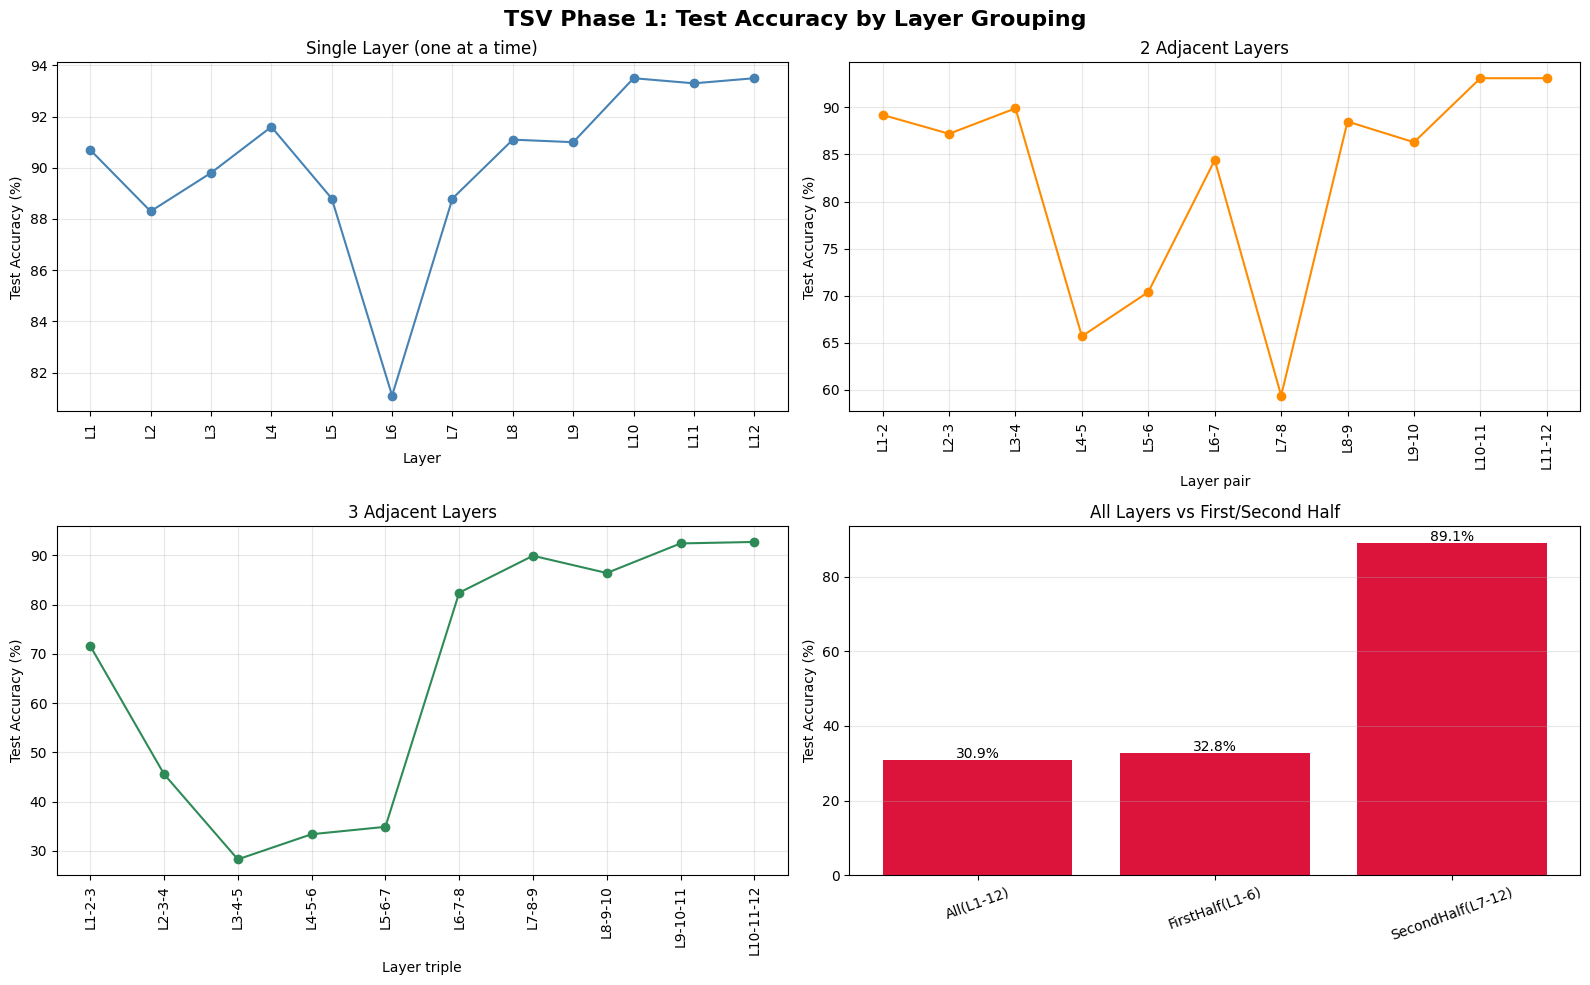


Top 5 layer groupings by accuracy:
  L10                  acc=93.50%  f1=0.9354  params=8,458
  L12                  acc=93.50%  f1=0.9351  params=8,458
  L11                  acc=93.30%  f1=0.9318  params=8,458
  L10-11               acc=93.10%  f1=0.9310  params=9,226
  L11-12               acc=93.10%  f1=0.9308  params=9,226


In [18]:
# Phase 1 results: table + graphs
singles  = [r for r in phase1_results if r['name'].startswith('L') and '-' not in r['name']]
pairs    = [r for r in phase1_results if r['name'].startswith('L') and r['name'].count('-') == 1]
triples  = [r for r in phase1_results if r['name'].startswith('L') and r['name'].count('-') == 2]
specials = [r for r in phase1_results if r['name'] in ('All(L1-12)', 'FirstHalf(L1-6)', 'SecondHalf(L7-12)')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('TSV Phase 1: Test Accuracy by Layer Grouping', fontsize=16, fontweight='bold')

ax = axes[0, 0]
ax.plot([r['name'] for r in singles], [r['test_acc'] for r in singles], marker='o', color='steelblue')
ax.set_title('Single Layer (one at a time)')
ax.set_xlabel('Layer'); ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot([r['name'] for r in pairs], [r['test_acc'] for r in pairs], marker='o', color='darkorange')
ax.set_title('2 Adjacent Layers')
ax.set_xlabel('Layer pair'); ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot([r['name'] for r in triples], [r['test_acc'] for r in triples], marker='o', color='seagreen')
ax.set_title('3 Adjacent Layers')
ax.set_xlabel('Layer triple'); ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
bars = ax.bar([r['name'] for r in specials], [r['test_acc'] for r in specials], color='crimson')
ax.set_title('All Layers vs First/Second Half')
ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=20); ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')

plt.tight_layout()
plt.savefig('tsv_phase1_layer_groupings.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 layer groupings by accuracy:")
for r in sorted(phase1_results, key=lambda r: -r['test_acc'])[:5]:
    print(f"  {r['name']:<20} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  params={r['trainable_params']:,}")


### Phase 2: Placement (`where`) Sweep (6 runs, best layer grouping from Phase 1, `lam=5.0` fixed)

In [19]:
PHASE2_EPOCHS = 3
best_layers = best_phase1['layer_indices']
best_layers_name = best_phase1['name']
phase2_results = []

print("="*70)
print(f"PHASE 2: PLACEMENT ('where') SWEEP  (layers={best_layers} [{best_layers_name}], lam=5.0 fixed)")
print("="*70)

phase2_start = time.time()
for w in wheres:
    print(f"\n--- where='{w}' ---")
    result = run_tsv_experiment(layer_indices=best_layers, where=w, lam=5.0, epochs=PHASE2_EPOCHS)
    result['name'] = w
    phase2_results.append(result)

phase2_elapsed = time.time() - phase2_start
print(f"\nPhase 2 total time: {phase2_elapsed/60:.1f} minutes")

best_phase2 = max(phase2_results, key=lambda r: r['test_acc'])
print(f"\nBest placement: where='{best_phase2['where']}' -> {best_phase2['test_acc']:.2f}% acc, F1={best_phase2['test_f1']:.4f}")


PHASE 2: PLACEMENT ('where') SWEEP  (layers=[9] [L10], lam=5.0 fixed)

--- where='residual' ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=residual  lam=5.0  -> acc=92.00%  f1=0.9181  (17.9s)

--- where='attn' ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn  lam=5.0  -> acc=93.60%  f1=0.9357  (18.2s)

--- where='mlp' ---


...

  layers=[9]  where=attn_mlp  lam=5.0  -> acc=82.90%  f1=0.8252  (18.3s)

--- where='attn_residual' ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn_residual  lam=5.0  -> acc=93.50%  f1=0.9352  (18.3s)

--- where='mlp_residual' ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=mlp_residual  lam=5.0  -> acc=93.30%  f1=0.9332  (17.8s)

Phase 2 total time: 2.0 minutes

Best placement: where='attn' -> 93.60% acc, F1=0.9357


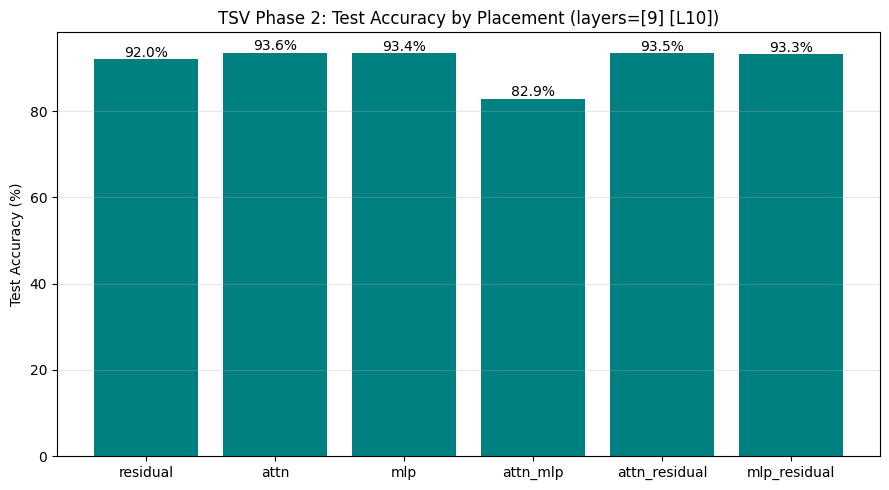


All Phase 2 results, sorted:
  where=attn            acc=93.60%  f1=0.9357  params=8,458
  where=attn_residual   acc=93.50%  f1=0.9352  params=9,226
  where=mlp             acc=93.40%  f1=0.9340  params=8,458
  where=mlp_residual    acc=93.30%  f1=0.9332  params=9,226
  where=residual        acc=92.00%  f1=0.9181  params=8,458
  where=attn_mlp        acc=82.90%  f1=0.8252  params=9,226


In [20]:
# Phase 2 results: graph
fig, ax = plt.subplots(figsize=(9, 5))
names = [r['name'] for r in phase2_results]
accs = [r['test_acc'] for r in phase2_results]
bars = ax.bar(names, accs, color='teal')
ax.set_title(f"TSV Phase 2: Test Accuracy by Placement (layers={best_layers} [{best_layers_name}])")
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_phase2_where.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 2 results, sorted:")
for r in sorted(phase2_results, key=lambda r: -r['test_acc']):
    print(f"  where={r['where']:<15} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  params={r['trainable_params']:,}")


### Phase 3: Steering Strength (`lam`) Sweep (5 runs, best layer grouping + placement from Phases 1-2)

In [21]:
PHASE3_EPOCHS = 3
best_where = best_phase2['where']
phase3_results = []

print("="*70)
print(f"PHASE 3: STEERING STRENGTH SWEEP  (layers={best_layers} [{best_layers_name}], where='{best_where}')")
print("="*70)

phase3_start = time.time()
for lam in lams:
    print(f"\n--- lam={lam} ---")
    result = run_tsv_experiment(layer_indices=best_layers, where=best_where, lam=lam, epochs=PHASE3_EPOCHS)
    result['name'] = f'lam={lam}'
    phase3_results.append(result)

phase3_elapsed = time.time() - phase3_start
print(f"\nPhase 3 total time: {phase3_elapsed/60:.1f} minutes")

best_phase3 = max(phase3_results, key=lambda r: r['test_acc'])
print(f"\nBest steering strength: lam={best_phase3['lam']} -> {best_phase3['test_acc']:.2f}% acc, F1={best_phase3['test_f1']:.4f}")


PHASE 3: STEERING STRENGTH SWEEP  (layers=[9] [L10], where='attn')

--- lam=0.1 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn  lam=0.1  -> acc=95.10%  f1=0.9507  (18.2s)

--- lam=0.5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn  lam=0.5  -> acc=95.00%  f1=0.9499  (18.3s)

--- lam=1 ---


...

  layers=[9]  where=attn  lam=1  -> acc=94.80%  f1=0.9477  (18.2s)

--- lam=5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn  lam=5  -> acc=93.70%  f1=0.9370  (18.1s)

--- lam=10 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[9]  where=attn  lam=10  -> acc=89.10%  f1=0.8911  (18.1s)

Phase 3 total time: 1.7 minutes

Best steering strength: lam=0.1 -> 95.10% acc, F1=0.9507


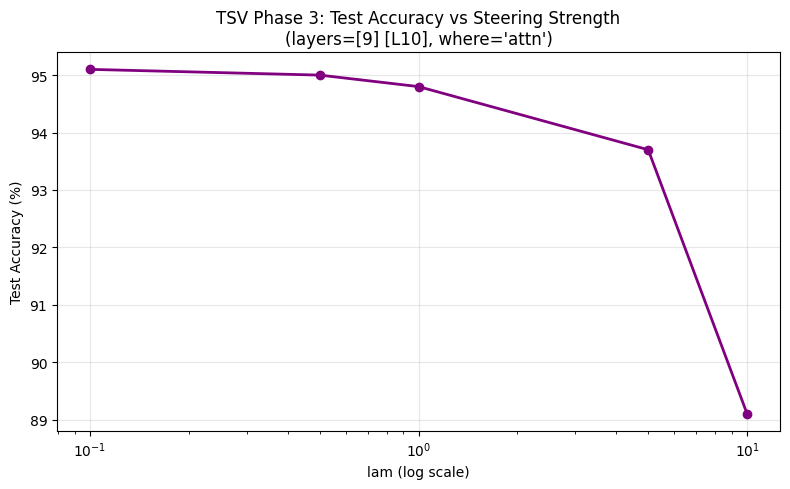


All Phase 3 results:
  lam=0.1    acc=95.10%  f1=0.9507
  lam=0.5    acc=95.00%  f1=0.9499
  lam=1      acc=94.80%  f1=0.9477
  lam=5      acc=93.70%  f1=0.9370
  lam=10     acc=89.10%  f1=0.8911


In [22]:
# Phase 3 results: graph
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['lam'] for r in phase3_results]
ys = [r['test_acc'] for r in phase3_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='purple')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 3: Test Accuracy vs Steering Strength\n(layers={best_layers} [{best_layers_name}], where='{best_where}')")
ax.set_xlabel('lam (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_phase3_lam.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 3 results:")
for r in phase3_results:
    print(f"  lam={r['lam']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Summary: Best TSV Configuration Found, and Saving All Results

In [23]:
all_tsv_study_results = phase1_results + phase2_results + phase3_results
best_overall = max(all_tsv_study_results, key=lambda r: r['test_acc'])

total_study_time = phase1_elapsed + phase2_elapsed + phase3_elapsed

print("="*70)
print("BEST TSV CONFIGURATION FOUND")
print("="*70)
print(f"Layers:            {best_overall['layer_indices']}  ({best_overall['name'] if 'L' in str(best_overall.get('name','')) else best_layers_name})")
print(f"Placement (where): {best_overall['where']}")
print(f"Steering strength: {best_overall['lam']}")
print(f"Test Accuracy:     {best_overall['test_acc']:.2f}%")
print(f"Test F1:           {best_overall['test_f1']:.4f}")
print(f"Trainable params:  {best_overall['trainable_params']:,}")
print(f"\nTotal study time: {total_study_time/60:.1f} minutes "
      f"({len(all_tsv_study_results)} runs: {len(phase1_results)} layer + "
      f"{len(phase2_results)} placement + {len(phase3_results)} strength)")

# Save everything to Drive
from pathlib import Path
import json, shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

tsv_study_summary = {
    'phase1_layer_groupings': phase1_results,
    'phase2_where': phase2_results,
    'phase3_lam': phase3_results,
    'best_overall': best_overall,
    'total_time_minutes': total_study_time / 60,
}

with open(results_dir / 'tsv_full_study.json', 'w') as f:
    json.dump(tsv_study_summary, f, indent=2)

for fname in ['tsv_phase1_layer_groupings.png', 'tsv_phase2_where.png', 'tsv_phase3_lam.png']:
    shutil.copy(fname, results_dir / fname)

print(f"\n✓ Full TSV study (results + all 3 graphs) saved to {results_dir}")


BEST TSV CONFIGURATION FOUND
Layers:            [9]  (L10)
Placement (where): attn
Steering strength: 0.1
Test Accuracy:     95.10%
Test F1:           0.9507
Trainable params:  8,458

Total study time: 17.3 minutes (47 runs: 36 layer + 6 placement + 5 strength)

✓ Full TSV study (results + all 3 graphs) saved to /content/drive/MyDrive/PEFT_Results


## 5.2 Data & Optimization Sweep: Training Set Size, Batch Size, Learning Rate

Three more practical questions, each tested as its own sweep (same
one-factor-at-a-time approach as the layer/placement/strength study
above) -- using whatever **layer grouping, placement, and steering
strength** the Phase 1-3 study above found best (`best_layers`,
`best_where`, and `best_overall['lam']`), so these results reflect TSV's
best-known configuration rather than the arbitrary defaults.

- **Training set size** -- how many labeled images does TSV actually
  need? (This is TSV's core selling point in the original paper: strong
  results from very little labeled data.)
- **Batch size** -- does it change final accuracy, not just speed?
- **Learning rate** -- how sensitive is TSV, compared to what we saw
  with LoRA earlier?

Each sweep trains fresh, small TSV models at a short `epochs` count (kept
short deliberately -- this is 14 more runs, not a final result) and
evaluates on the full, unchanged test set.

In [24]:
import time as _time

def run_tsv_experiment_v2(layer_indices, where, lam, epochs, lr, train_loader_to_use, verbose=True):
    """Same as run_tsv_experiment(), but lets you override the train_loader
    (for batch size / training set size sweeps) and the learning rate
    (for the LR sweep) independently of the global train_loader / LEARNING_RATE."""
    m = TSVClassificationModel(model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                                layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = _time.time()
    for epoch in range(epochs):
        train_epoch(m, train_loader_to_use, opt, crit, device, epoch, epochs)
    elapsed = _time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {'test_acc': test_acc, 'test_f1': test_f1,
              'trainable_params': trainable_params, 'time_seconds': elapsed}
    if verbose:
        print(f"    -> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


# Best configuration from the Phase 1-3 study above -- used as the fixed
# backbone/steering setup for all three sweeps below.
sweep_layers = best_layers
sweep_where = best_where
sweep_lam = best_overall['lam']
SWEEP_EPOCHS = 3  # kept short on purpose, same reasoning as Phase 1-3

print(f"Using best-found TSV configuration for all sweeps below:")
print(f"  layers={sweep_layers}  where='{sweep_where}'  lam={sweep_lam}")


Using best-found TSV configuration for all sweeps below:
  layers=[9]  where='attn'  lam=0.1


### Phase 4: Training Set Size Sweep (5 runs) -- how much labeled data does TSV need?

In [25]:
train_sizes = [100, 500, 1000, 2500, 5000]  # 5000 = the full subset this notebook uses
phase4_results = []

print("="*70)
print(f"PHASE 4: TRAINING SET SIZE SWEEP  (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
print("="*70)

phase4_start = time.time()
for size in train_sizes:
    print(f"\n--- train_size={size} ---")
    if size < len(train_dataset):
        size_subset, _ = random_split(train_dataset, [size, len(train_dataset) - size])
    else:
        size_subset = train_dataset
    size_loader = DataLoader(size_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment_v2(sweep_layers, sweep_where, sweep_lam, SWEEP_EPOCHS,
                                    LEARNING_RATE, size_loader)
    result['train_size'] = size
    phase4_results.append(result)

phase4_elapsed = time.time() - phase4_start
print(f"\nPhase 4 total time: {phase4_elapsed/60:.1f} minutes")

best_phase4 = max(phase4_results, key=lambda r: r['test_acc'])
print(f"\nBest training set size: {best_phase4['train_size']} -> {best_phase4['test_acc']:.2f}% acc")


PHASE 4: TRAINING SET SIZE SWEEP  (layers=[9], where='attn', lam=0.1)

--- train_size=100 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=85.70%  f1=0.8520  (0.8s)

--- train_size=500 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=93.80%  f1=0.9381  (2.2s)

--- train_size=1000 ---


...

    -> acc=93.40%  f1=0.9339  (3.8s)

--- train_size=2500 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=94.10%  f1=0.9406  (9.3s)

--- train_size=5000 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=95.00%  f1=0.9499  (18.1s)

Phase 4 total time: 0.8 minutes

Best training set size: 5000 -> 95.00% acc


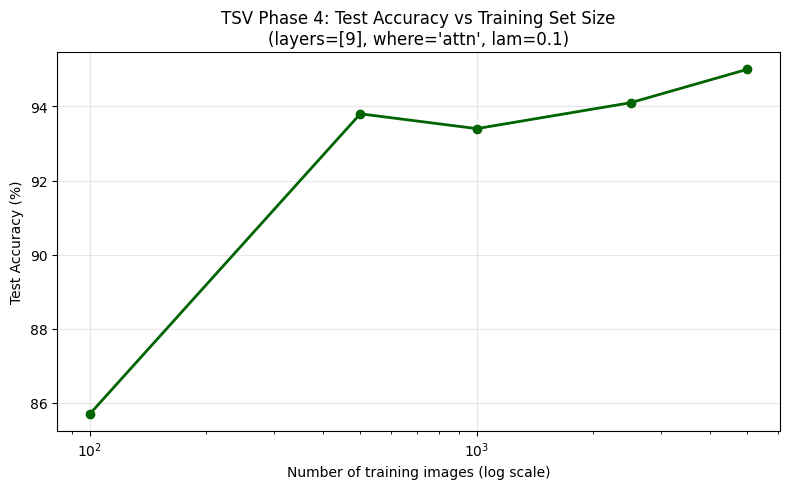


All Phase 4 results:
  train_size=100    acc=85.70%  f1=0.8520
  train_size=500    acc=93.80%  f1=0.9381
  train_size=1000   acc=93.40%  f1=0.9339
  train_size=2500   acc=94.10%  f1=0.9406
  train_size=5000   acc=95.00%  f1=0.9499


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['train_size'] for r in phase4_results]
ys = [r['test_acc'] for r in phase4_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='darkgreen')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 4: Test Accuracy vs Training Set Size\n(layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
ax.set_xlabel('Number of training images (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_phase4_train_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 4 results:")
for r in phase4_results:
    print(f"  train_size={r['train_size']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 5: Batch Size Sweep (4 runs)

In [27]:
batch_sizes = [16, 32, 64, 128]
phase5_results = []

print("="*70)
print(f"PHASE 5: BATCH SIZE SWEEP  (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
print("="*70)

phase5_start = time.time()
for bs in batch_sizes:
    print(f"\n--- batch_size={bs} ---")
    bs_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment_v2(sweep_layers, sweep_where, sweep_lam, SWEEP_EPOCHS,
                                    LEARNING_RATE, bs_loader)
    result['batch_size'] = bs
    phase5_results.append(result)

phase5_elapsed = time.time() - phase5_start
print(f"\nPhase 5 total time: {phase5_elapsed/60:.1f} minutes")

best_phase5 = max(phase5_results, key=lambda r: r['test_acc'])
print(f"\nBest batch size: {best_phase5['batch_size']} -> {best_phase5['test_acc']:.2f}% acc")


PHASE 5: BATCH SIZE SWEEP  (layers=[9], where='attn', lam=0.1)

--- batch_size=16 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=95.10%  f1=0.9510  (20.0s)

--- batch_size=32 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=95.00%  f1=0.9500  (17.7s)

--- batch_size=64 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=94.80%  f1=0.9479  (18.2s)

--- batch_size=128 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=95.20%  f1=0.9520  (17.3s)

Phase 5 total time: 1.4 minutes

Best batch size: 128 -> 95.20% acc


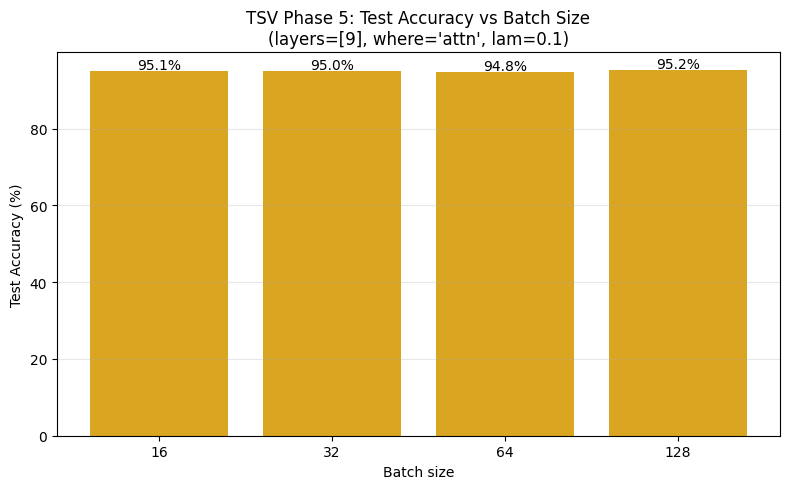


All Phase 5 results:
  batch_size=16    acc=95.10%  f1=0.9510  time=20.0s
  batch_size=32    acc=95.00%  f1=0.9500  time=17.7s
  batch_size=64    acc=94.80%  f1=0.9479  time=18.2s
  batch_size=128   acc=95.20%  f1=0.9520  time=17.3s


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
names = [str(r['batch_size']) for r in phase5_results]
accs = [r['test_acc'] for r in phase5_results]
bars = ax.bar(names, accs, color='goldenrod')
ax.set_title(f"TSV Phase 5: Test Accuracy vs Batch Size\n(layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
ax.set_xlabel('Batch size')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_phase5_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 5 results:")
for r in phase5_results:
    print(f"  batch_size={r['batch_size']:<5} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  time={r['time_seconds']:.1f}s")


### Phase 6: Learning Rate Sweep (5 runs)

In [29]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
phase6_results = []

print("="*70)
print(f"PHASE 6: LEARNING RATE SWEEP  (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
print("="*70)

phase6_start = time.time()
for lr in learning_rates:
    print(f"\n--- learning_rate={lr} ---")
    result = run_tsv_experiment_v2(sweep_layers, sweep_where, sweep_lam, SWEEP_EPOCHS,
                                    lr, train_loader)
    result['learning_rate'] = lr
    phase6_results.append(result)

phase6_elapsed = time.time() - phase6_start
print(f"\nPhase 6 total time: {phase6_elapsed/60:.1f} minutes")

best_phase6 = max(phase6_results, key=lambda r: r['test_acc'])
print(f"\nBest learning rate: {best_phase6['learning_rate']} -> {best_phase6['test_acc']:.2f}% acc")


PHASE 6: LEARNING RATE SWEEP  (layers=[9], where='attn', lam=0.1)

--- learning_rate=0.001 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=94.40%  f1=0.9442  (18.2s)

--- learning_rate=0.005 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=95.60%  f1=0.9560  (16.9s)

--- learning_rate=0.01 ---


...

    -> acc=95.20%  f1=0.9520  (16.9s)

--- learning_rate=0.05 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=93.70%  f1=0.9373  (18.1s)

--- learning_rate=0.1 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    -> acc=92.40%  f1=0.9245  (18.1s)

Phase 6 total time: 1.6 minutes

Best learning rate: 0.005 -> 95.60% acc


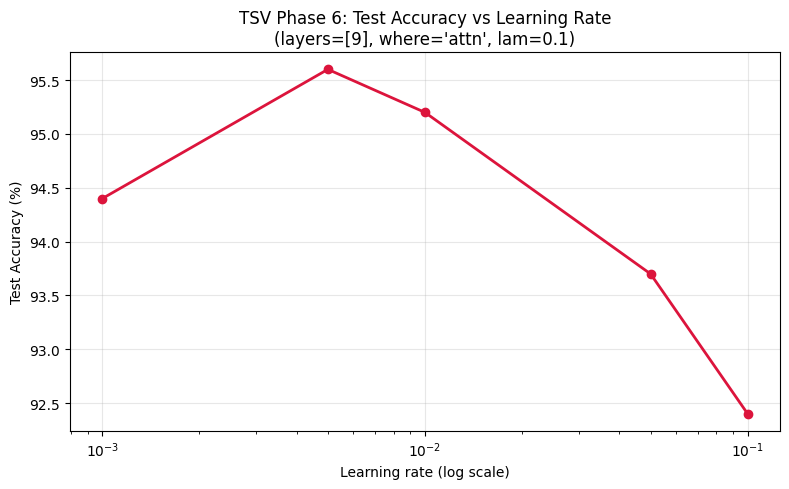


All Phase 6 results:
  lr=0.001   acc=94.40%  f1=0.9442
  lr=0.005   acc=95.60%  f1=0.9560
  lr=0.01    acc=95.20%  f1=0.9520
  lr=0.05    acc=93.70%  f1=0.9373
  lr=0.1     acc=92.40%  f1=0.9245


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['learning_rate'] for r in phase6_results]
ys = [r['test_acc'] for r in phase6_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='crimson')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 6: Test Accuracy vs Learning Rate\n(layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam})")
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_phase6_learning_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 6 results:")
for r in phase6_results:
    print(f"  lr={r['learning_rate']:<7} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 4-6 Summary: Saving Results

In [31]:
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

param_sweep_summary = {
    'fixed_config': {'layers': sweep_layers, 'where': sweep_where, 'lam': sweep_lam},
    'phase4_train_size': phase4_results,
    'phase5_batch_size': phase5_results,
    'phase6_learning_rate': phase6_results,
    'best_train_size': best_phase4['train_size'],
    'best_batch_size': best_phase5['batch_size'],
    'best_learning_rate': best_phase6['learning_rate'],
}

with open(results_dir / 'tsv_param_sweep.json', 'w') as f:
    json.dump(param_sweep_summary, f, indent=2)

for fname in ['tsv_phase4_train_size.png', 'tsv_phase5_batch_size.png', 'tsv_phase6_learning_rate.png']:
    shutil.copy(fname, results_dir / fname)

total_sweep_time = phase4_elapsed + phase5_elapsed + phase6_elapsed
print(f"Total Phase 4-6 time: {total_sweep_time/60:.1f} minutes "
      f"({len(train_sizes)+len(batch_sizes)+len(learning_rates)} runs)")
print(f"\n✓ Parameter sweep results + graphs saved to {results_dir}")


Total Phase 4-6 time: 3.8 minutes (14 runs)

✓ Parameter sweep results + graphs saved to /content/drive/MyDrive/PEFT_Results


## 5.3 Parameter Efficiency Analysis

The whole point of TSV (and PEFT methods generally) is accuracy **per
trainable parameter**, not just raw accuracy. This section costs almost
nothing extra:

- It reuses `phase1_results` and `phase2_results` from the study above --
  no new training needed, since `trainable_params` was already recorded
  for every one of those 42 runs.
- It adds exactly **one new run**: a **linear probe** baseline --
  `layer_indices=[]` means TSV registers zero hooks and zero steering
  vectors, so this trains *only* the classifier head on frozen CLIP
  features. This tells us how much of TSV's accuracy is actually coming
  from the steering vector itself, versus just having a trained
  classifier on top of frozen features.

In [32]:
print("="*70)
print("LINEAR PROBE BASELINE  (layer_indices=[] -- zero TSV vectors, classifier only)")
print("="*70)

linear_probe_result = run_tsv_experiment(layer_indices=[], where='residual', lam=0.0, epochs=SWEEP_EPOCHS)
linear_probe_result['name'] = 'Linear Probe (0 TSV params)'

print(f"\nLinear probe: acc={linear_probe_result['test_acc']:.2f}%  "
      f"f1={linear_probe_result['test_f1']:.4f}  "
      f"trainable_params={linear_probe_result['trainable_params']:,} (classifier head only)")


LINEAR PROBE BASELINE  (layer_indices=[] -- zero TSV vectors, classifier only)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  layers=[]  where=residual  lam=0.0  -> acc=94.30%  f1=0.9428  (16.3s)

Linear probe: acc=94.30%  f1=0.9428  trainable_params=7,690 (classifier head only)


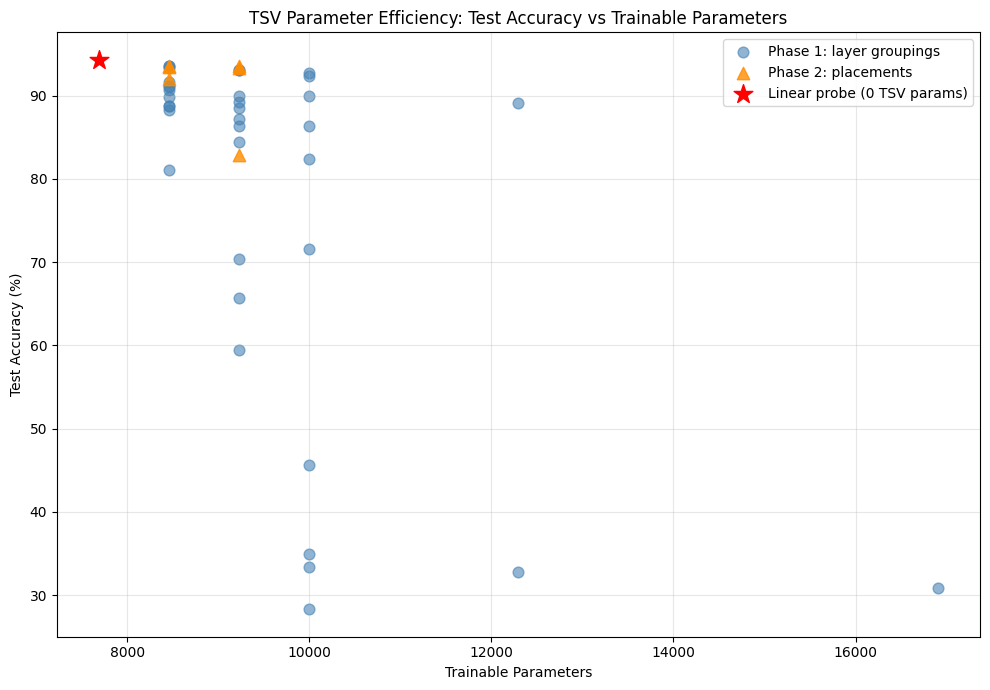


Linear probe (0 TSV params) baseline accuracy: 94.30%

Config                    Params     Acc      Acc gain over probe  Gain per 1K params  
-------------------------------------------------------------------------------------
attn_residual             9,226      93.50    -0.80                -0.521              
mlp_residual              9,226      93.30    -1.00                -0.651              
L10-11-12                 9,994      92.70    -1.60                -0.694              
L10-11                    9,226      93.10    -1.20                -0.781              
L11-12                    9,226      93.10    -1.20                -0.781              
L9-10-11                  9,994      92.40    -1.90                -0.825              
attn                      8,458      93.60    -0.70                -0.911              
L10                       8,458      93.50    -0.80                -1.042              
L12                       8,458      93.50    -0.80               

In [33]:
# Combine everything we have trainable_params + test_acc for: Phase 1
# (layer groupings), Phase 2 (placements), and the linear probe baseline.
all_efficiency_results = phase1_results + phase2_results + [linear_probe_result]

fig, ax = plt.subplots(figsize=(10, 7))

phase1_params = [r['trainable_params'] for r in phase1_results]
phase1_accs = [r['test_acc'] for r in phase1_results]
ax.scatter(phase1_params, phase1_accs, alpha=0.6, s=60, color='steelblue', label='Phase 1: layer groupings')

phase2_params = [r['trainable_params'] for r in phase2_results]
phase2_accs = [r['test_acc'] for r in phase2_results]
ax.scatter(phase2_params, phase2_accs, alpha=0.8, s=80, color='darkorange', marker='^', label='Phase 2: placements')

ax.scatter([linear_probe_result['trainable_params']], [linear_probe_result['test_acc']],
           s=200, color='red', marker='*', label='Linear probe (0 TSV params)', zorder=5)

ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('TSV Parameter Efficiency: Test Accuracy vs Trainable Parameters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsv_parameter_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Efficiency ranking: accuracy gained per 1,000 trainable parameters,
# measured above the linear-probe floor (so it reflects what the STEERING
# VECTOR itself is contributing, not the classifier head every config shares).
baseline_acc = linear_probe_result['test_acc']
print(f"\nLinear probe (0 TSV params) baseline accuracy: {baseline_acc:.2f}%\n")

print(f"{'Config':<25} {'Params':<10} {'Acc':<8} {'Acc gain over probe':<20} {'Gain per 1K params':<20}")
print("-" * 85)
for r in sorted(phase1_results + phase2_results, key=lambda r: -(r['test_acc'] - baseline_acc) / max(r['trainable_params'] - linear_probe_result['trainable_params'], 1)):
    name = r.get('name', r.get('where', '?'))
    extra_params = r['trainable_params'] - linear_probe_result['trainable_params']
    acc_gain = r['test_acc'] - baseline_acc
    gain_per_1k = (acc_gain / extra_params) * 1000 if extra_params > 0 else 0
    print(f"{str(name):<25} {r['trainable_params']:<10,} {r['test_acc']:<8.2f} {acc_gain:<20.2f} {gain_per_1k:<20.3f}")


In [34]:
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

efficiency_summary = {
    'linear_probe_baseline': linear_probe_result,
    'phase1_layer_groupings': phase1_results,
    'phase2_where': phase2_results,
}

with open(results_dir / 'tsv_parameter_efficiency.json', 'w') as f:
    json.dump(efficiency_summary, f, indent=2)

shutil.copy('tsv_parameter_efficiency.png', results_dir / 'tsv_parameter_efficiency.png')

print(f"✓ Parameter efficiency analysis + graph saved to {results_dir}")


✓ Parameter efficiency analysis + graph saved to /content/drive/MyDrive/PEFT_Results


## 6. TSV Method Characteristics

In [35]:
print("\n" + "="*80)
print("TSV METHOD ANALYSIS")
print("="*80)

analysis = """
### TSV (Trainable Steering Vector)
- **Principle**: Adds one trainable vector to the residual stream (or
  attention/MLP output) at a chosen transformer block, steering the whole
  downstream representation without touching any of the backbone's own weights
- **Key Features**:
  * No Linear-layer targeting decision needed -- one vector per steered layer
  * Backbone stays entirely frozen; only the vector(s) + classifier head train
  * Placement (attn / mlp / residual / combinations) and layer position are
    free design choices, explored in the full study above
- **Advantages**:
  * Extremely small number of trainable parameters (thousands, not millions)
  * Simple mechanism (forward hook, no weight-matrix decomposition)
  * No target-module search needed, unlike LoRA-style methods
- **Sensitivities** (from the full study above):
  * Steering strength (`lam`) matters a lot -- too small has no effect,
    too large destroys the representation
  * Steering too many layers at once can hurt more than help
  * Layer position and placement both affect performance meaningfully
"""

print(analysis)



TSV METHOD ANALYSIS

### TSV (Trainable Steering Vector)
- **Principle**: Adds one trainable vector to the residual stream (or
  attention/MLP output) at a chosen transformer block, steering the whole
  downstream representation without touching any of the backbone's own weights
- **Key Features**:
  * No Linear-layer targeting decision needed -- one vector per steered layer
  * Backbone stays entirely frozen; only the vector(s) + classifier head train
  * Placement (attn / mlp / residual / combinations) and layer position are
    free design choices, explored in the full study above
- **Advantages**:
  * Extremely small number of trainable parameters (thousands, not millions)
  * Simple mechanism (forward hook, no weight-matrix decomposition)
  * No target-module search needed, unlike LoRA-style methods
- **Sensitivities** (from the full study above):
  * Steering strength (`lam`) matters a lot -- too small has no effect,
    too large destroys the representation
  * Steering too man

## 7. Checkpoint Management and Inference

In [36]:
print("Loading saved TSV checkpoint for inference...")

try:
    # Rebuild a TSV model with the SAME layer_indices / where / lam used for
    # the checkpoint you want to reload -- these must match what you trained,
    # since the hook locations are set up at construction time, not restored
    # automatically from the saved state dict.
    tsv_inference_model = TSVClassificationModel(
        model_name=OPENCLIP_MODEL_NAME,
        num_classes=10,
        layer_indices=None,   # <- match whatever you trained with
        lam=5.0,
        where='residual'
    ).to(device)

    tsv_inference_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth', map_location=device))
    tsv_inference_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth', map_location=device))

    tsv_inference_model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1 = evaluate(tsv_inference_model, test_loader, criterion, device)

    print(f"\nTSV Inference Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print("\n✓ Successfully loaded and evaluated TSV checkpoint!")
except Exception as e:
    print(f"Note: Checkpoint loading example (optional). Error: {e}")


Loading saved TSV checkpoint for inference...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


TSV Inference Results:
  Test Loss: 0.1060
  Test Accuracy: 96.10%
  Test F1-Score: 0.9610

✓ Successfully loaded and evaluated TSV checkpoint!


## 8. Export and Deployment Instructions

In [37]:
deployment_guide = """
# DEPLOYMENT GUIDE (TSV)

## Saving a TSV steering vector + classifier head
```python
os.makedirs('./tsv_best_model', exist_ok=True)
torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
```

## Loading it back
```python
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME, num_classes=10,
    layer_indices=[4], lam=5.0, where='residual'   # must match training config
).to(device)
tsv_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth'))
tsv_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth'))
```

## Removing the steering (back to plain, unsteered backbone)
```python
tsv_model.tsv.remove_hooks()
```
Unlike LoRA/DoRA, there's no `merge_and_unload()` step -- TSV never modified
any backbone weights in the first place, so removing the hooks is enough.

## Inference Pipeline

```python
from torchvision.transforms import Resize
import torch

def predict(image, model, device):
    resizer = Resize((224, 224))
    image = resizer(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)
        pred_class = logits.argmax(dim=1).item()

    return pred_class, probs.cpu().numpy()[0]
```

## Model Size
- OpenCLIP ViT-B/32 backbone: ~88M parameters (entirely frozen)
- TSV vector(s): a few KB per steered layer/placement (hidden_size=768 floats each)
- Classifier head: 768 x num_classes + num_classes params

## Performance Tips
1. Use `device_map='auto'` for automatic GPU memory management on larger backbones
2. Enable `torch.cuda.amp.autocast()` for mixed precision inference
3. Batch multiple images for better GPU utilization
4. Since the backbone is untouched, the SAME frozen backbone can be shared
   across multiple different TSV vectors (e.g. one per task) without
   duplicating the ~88M backbone parameters each time
"""

print(deployment_guide)

with open('DEPLOYMENT_GUIDE.md', 'w') as f:
    f.write(deployment_guide)

print("\n✓ Deployment guide saved to 'DEPLOYMENT_GUIDE.md'")



# DEPLOYMENT GUIDE (TSV)

## Saving a TSV steering vector + classifier head
```python
os.makedirs('./tsv_best_model', exist_ok=True)
torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
```

## Loading it back
```python
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME, num_classes=10,
    layer_indices=[4], lam=5.0, where='residual'   # must match training config
).to(device)
tsv_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth'))
tsv_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth'))
```

## Removing the steering (back to plain, unsteered backbone)
```python
tsv_model.tsv.remove_hooks()
```
Unlike LoRA/DoRA, there's no `merge_and_unload()` step -- TSV never modified
any backbone weights in the first place, so removing the hooks is enough.

## Inference Pipeline

```python
from torchvision.transforms i

## 9. Summary and Key Takeaways

In [38]:
tsv_best_epoch = tsv_history['test_acc'].index(max(tsv_history['test_acc']))
tsv_best_f1 = tsv_history['test_f1'][tsv_best_epoch]

summary = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    TSV FINE-TUNING SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════════╝

MAIN RUN (Section 5) -- layer=auto-picked early-middle, where='residual', lam=5.0
   - Training Time: {training_time_tsv:.1f} seconds
   - Best Accuracy: {max(tsv_history['test_acc']):.2f}%
   - Best F1-Score: {tsv_best_f1:.4f}

FULL STUDY (Section 5.1) -- {len(all_tsv_study_results)} runs across 3 phases
   - Best configuration found:
       Layers:            {best_overall['layer_indices']}
       Placement (where): {best_overall['where']}
       Steering strength: {best_overall['lam']}
       Test Accuracy:     {best_overall['test_acc']:.2f}%
       Test F1:           {best_overall['test_f1']:.4f}
   - Total study time: {total_study_time/60:.1f} minutes

╔════════════════════════════════════════════════════════════════════════════╗
║                      FILES SAVED TO GOOGLE DRIVE                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Location: /content/drive/MyDrive/PEFT_Results/

  • tsv_full_study.json           - All 47 runs' full results
  • tsv_phase1_layer_groupings.png
  • tsv_phase2_where.png
  • tsv_phase3_lam.png

Additional files in working directory:
  • tsv_best_model/          - Main run's TSV vector(s) + classifier head
  • DEPLOYMENT_GUIDE.md      - Inference and deployment instructions

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary)

# Final summary JSON
final_summary = {
    'experiment': 'TSV_Fine_Tuning',
    'dataset': 'CIFAR-10',
    'model': OPENCLIP_MODEL_NAME,
    'configuration': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'train_samples': subset_size_train,
        'test_samples': subset_size_test
    },
    'main_run': {
        'best_accuracy': float(max(tsv_history['test_acc'])),
        'best_f1': float(tsv_best_f1),
        'training_time_seconds': training_time_tsv,
    },
    'full_study_best_config': best_overall,
    'full_study_total_runs': len(all_tsv_study_results),
    'timestamp': datetime.now().isoformat()
}

with open('experiment_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print("✓ Experiment summary saved to 'experiment_summary.json'")
print("\n" + "="*80)
print("ALL TSV TRAINING COMPLETE!")
print("="*80)



╔════════════════════════════════════════════════════════════════════════════╗
║                    TSV FINE-TUNING SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════════╝

MAIN RUN (Section 5) -- layer=auto-picked early-middle, where='residual', lam=5.0
   - Training Time: 84.1 seconds
   - Best Accuracy: 96.10%
   - Best F1-Score: 0.9610

FULL STUDY (Section 5.1) -- 47 runs across 3 phases
   - Best configuration found:
       Layers:            [9]
       Placement (where): attn
       Steering strength: 0.1
       Test Accuracy:     95.10%
       Test F1:           0.9507
   - Total study time: 17.3 minutes

╔════════════════════════════════════════════════════════════════════════════╗
║                      FILES SAVED TO GOOGLE DRIVE                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Location: /content/drive/MyDrive/PEFT_Results/

  • tsv_full_study.json       